In [1]:
import torch
import torch.nn as nn
from dinov2_model import DINOv2Classifier
import xml.etree.ElementTree as ET
import pandas as pd
from IPython.display import display, HTML
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import requests
import os
from pathlib import Path
from time import sleep
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import torch
import torch.nn as nn
from torchvision import models
from torch.utils.data import DataLoader
from torch.cuda.amp import GradScaler, autocast
from torchvision import models, transforms
import cv2
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Subset
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
import torchmetrics

In [2]:

tree = ET.parse(r"C:\Users\emilm\OneDrive - University of Copenhagen\UNI Ting\4. år\Applied Machine Learning\FinalProject\CardDefs.xml")
root = tree.getroot()

records = []

for entity in root.findall("Entity"):
    row = {
        "CardID": entity.get("CardID"),
        "ID": entity.get("ID"),
        "version": entity.get("version"),
    }

    for tag in entity.findall("Tag"):
        name = tag.get("name")
        tag_type = tag.get("type")

        if tag_type == "LocString":
            # Grab the English text if available
            en = tag.find("enUS")
            row[name] = en.text.strip() if en is not None and en.text else None
        elif tag_type in ("Int", "String"):
            # Value is either an attribute or text content
            row[name] = tag.get("value") or tag.text
        else:
            row[name] = tag.get("value") or tag.text

    records.append(row)

df = pd.DataFrame(records)
print(df.shape)
print(df.head())

(34954, 2986)
                                  CardID      ID version  \
0        AIBot_DemonHunterTrainee_001_hb   91661       2   
1              AIBot_DruidTrainee_002_hb   91662       2   
2  AIBot_Event_Ragnaros_FireFestival_02m  104998       2   
3             AIBot_HunterTrainee_003_hb   91663       2   
4               AIBot_MageTrainee_004_hb   91664       2   

                 CARDNAME HEALTH CARD_SET CLASS FACTION CARDTYPE HERO_POWER  \
0     DemonHunter Trainee     30     1658    14       3        3      60224   
1           Druid Trainee     30     1658     2       3        3       1123   
2  Fire Festival Ragnaros     30       18     8       3        3      74588   
3          Hunter Trainee     30     1658     3       3        3        229   
4            Mage Trainee     30     1658     4       3        3        807   

   ... 2571 105687 40679 41672 40213 40950 IGNORE_SUPPRESS_MILL_ANIMATION  \
0  ...  NaN    NaN   NaN   NaN   NaN   NaN                            NaN

In [3]:
threshold = 0.95
df_filtered = df.loc[:, df.isnull().mean() < threshold]
print(df_filtered.shape)
print(df_filtered.columns.tolist())

(34954, 29)
['CardID', 'ID', 'version', 'CARDNAME', 'HEALTH', 'CARD_SET', 'CLASS', 'FACTION', 'CARDTYPE', 'HERO_POWER', 'HIDE_WATERMARK', 'ARTISTNAME', 'RARITY', 'AttackVisualType', 'CARDTEXT', 'FLAVORTEXT', 'COST', 'COLLECTIBLE', 'SPELL_SCHOOL', 'ATK', 'CARDRACE', 'BATTLECRY', 'ELITE', 'TRIGGER_VISUAL', '1', 'TECH_LEVEL', 'TAG_SCRIPT_DATA_NUM_1', 'HIDE_COST', 'TAG_SCRIPT_DATA_NUM_2']


In [4]:
cols_to_keep = [
    "CardID", "ID",
    "CARDNAME", "CARDTEXT", "FLAVORTEXT",
    "COST", "ATK", "HEALTH",
    "CLASS", "CARDTYPE", "CARDRACE",
    "RARITY", "CARD_SET",
    "COLLECTIBLE",
    "BATTLECRY", "DEATHRATTLE", "INSPIRE",
    "SECRET", "COMBO", "CHARGE", "TAUNT",
    "DIVINE_SHIELD", "STEALTH", "POISONOUS",
    "SPELL_SCHOOL", "ELITE",
    "ARTISTNAME",
]

# Only keep columns that actually exist in the dataframe
cols_present = [c for c in cols_to_keep if c in df.columns]
df_clean = df[cols_present]
print(df_clean.shape)

(34954, 27)


In [5]:
df_clean_collectible = df_clean[df_clean["COLLECTIBLE"] == "1"].reset_index(drop=True)
print(df_clean_collectible.shape)

(7935, 27)


In [6]:
df_clean_collectible0 = df_clean_collectible.fillna(0)

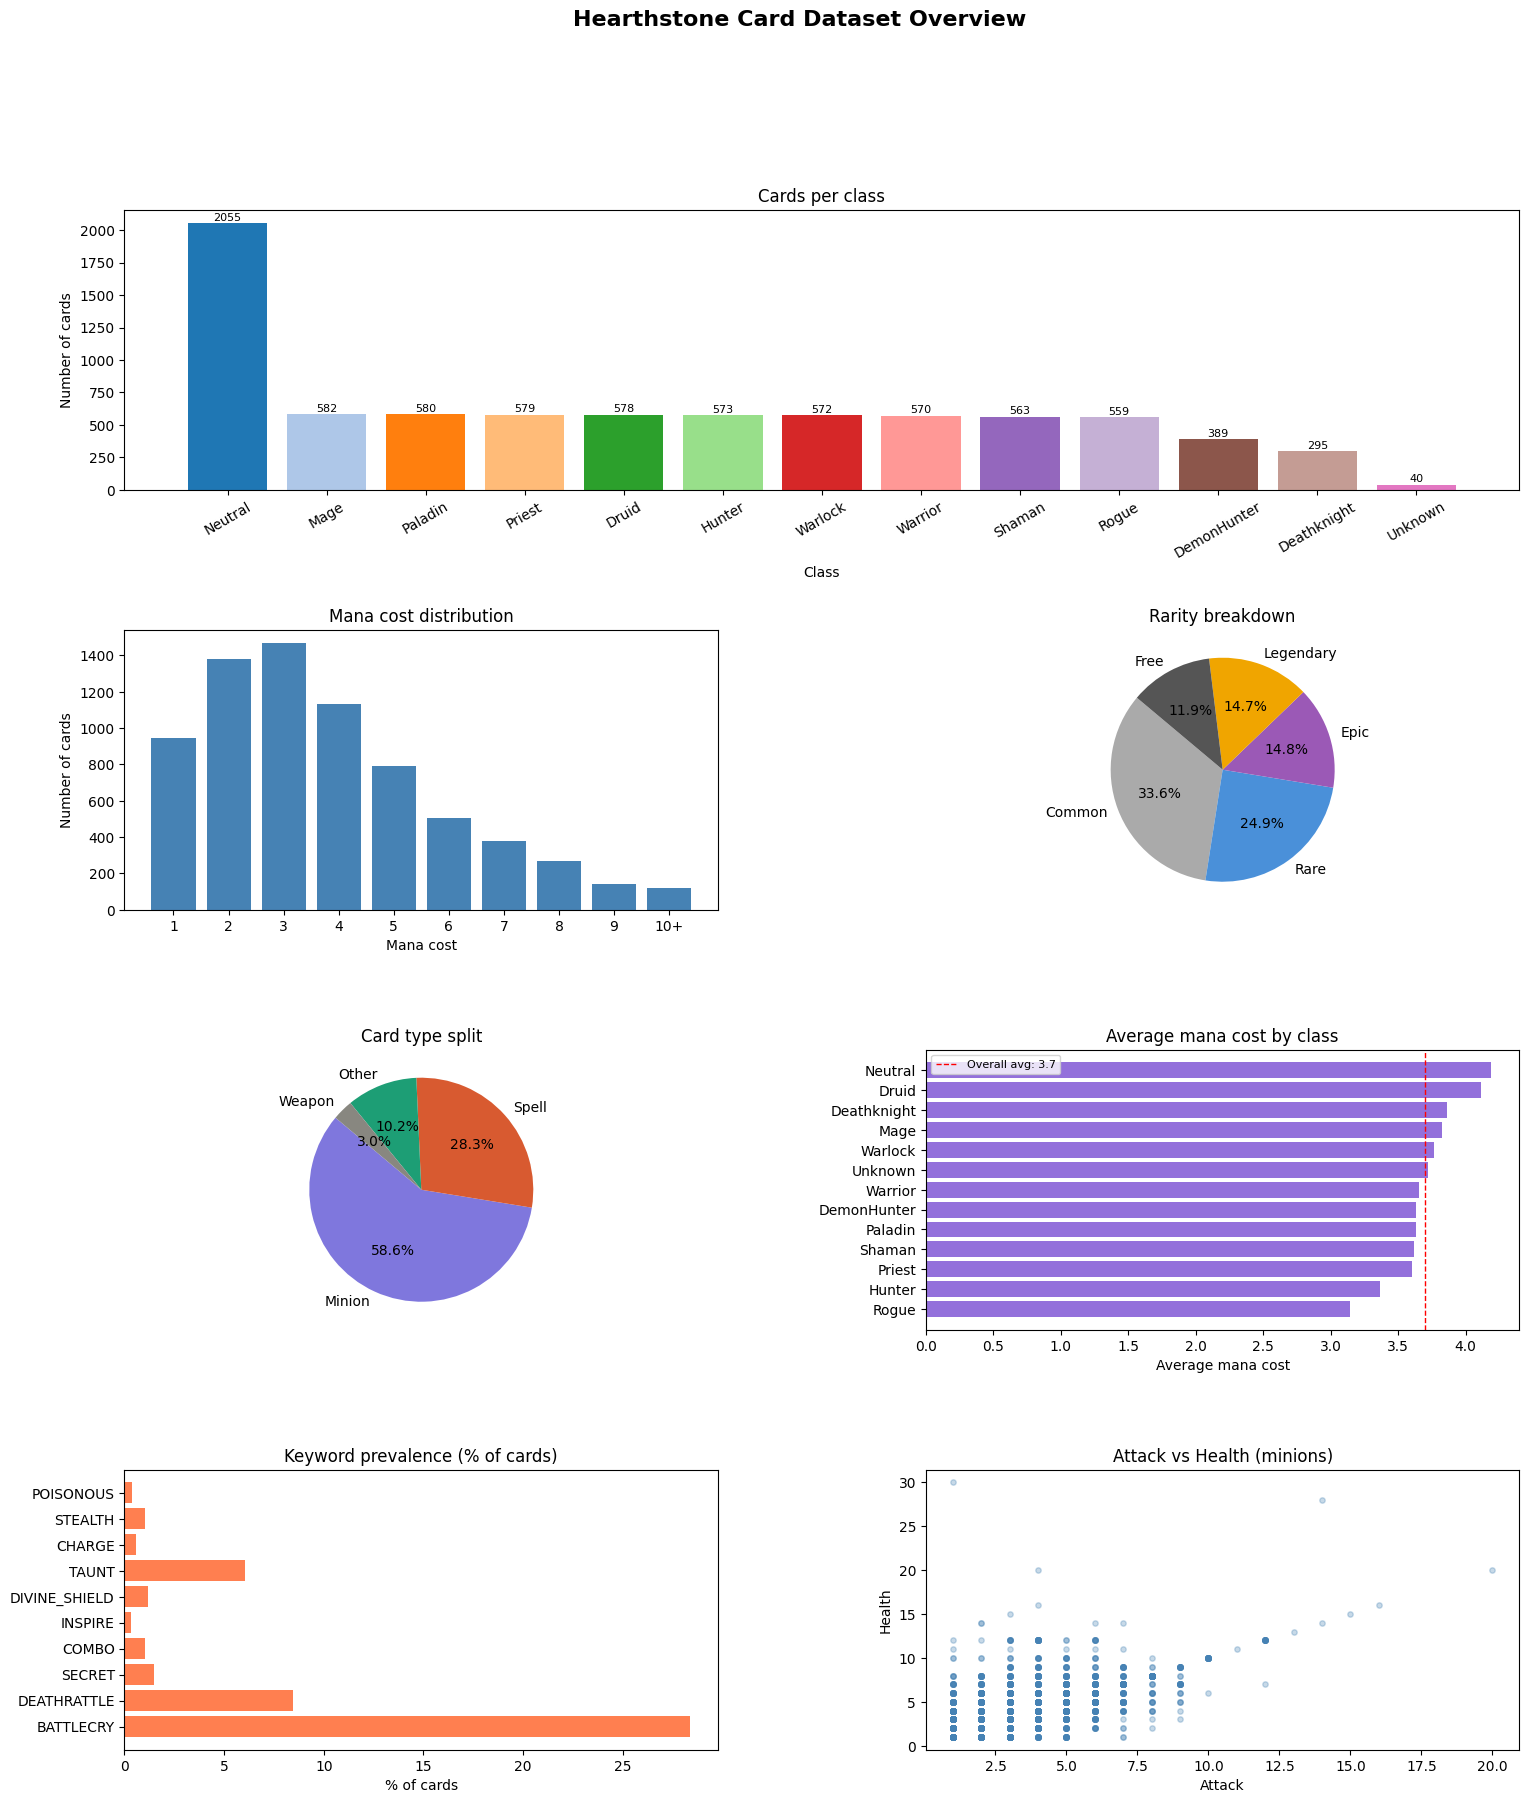

In [7]:

CLASS_MAP = {
    '1':'Deathknight','2':'Druid','3':'Hunter','4':'Mage','5':'Paladin',
    '6':'Priest','7':'Rogue','8':'Shaman','9':'Warlock','10':'Warrior',
    '12':'Neutral','14':'DemonHunter'
}
RARITY_MAP = {'1':'Common','2':'Free','3':'Rare','4':'Epic','5':'Legendary'}
TYPE_MAP = {'4':'Minion','5':'Spell','7':'Weapon'}

df = df_clean_collectible.copy()
df['CLASS'] = df['CLASS'].astype(str).map(CLASS_MAP).fillna('Unknown')
df['RARITY'] = df['RARITY'].astype(str).map(RARITY_MAP).fillna('Unknown')
df['CARDTYPE'] = df['CARDTYPE'].astype(str).map(TYPE_MAP).fillna('Other')
df['COST'] = pd.to_numeric(df['COST'], errors='coerce')
df['ATK'] = pd.to_numeric(df['ATK'], errors='coerce')
df['HEALTH'] = pd.to_numeric(df['HEALTH'], errors='coerce')

minions = df[df['CARDTYPE'] == 'Minion']

keywords = ['BATTLECRY','DEATHRATTLE','SECRET','COMBO','INSPIRE',
            'DIVINE_SHIELD','TAUNT','CHARGE','STEALTH','POISONOUS']
keywords = [k for k in keywords if k in df.columns]

fig = plt.figure(figsize=(18, 20))
fig.suptitle('Hearthstone Card Dataset Overview', fontsize=16, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.5, wspace=0.35)

# 1. Cards per class
ax1 = fig.add_subplot(gs[0, :])
class_counts = df['CLASS'].value_counts().sort_values(ascending=False)
bars = ax1.bar(class_counts.index, class_counts.values, color=plt.cm.tab20.colors[:len(class_counts)])
ax1.set_title('Cards per class')
ax1.set_xlabel('Class')
ax1.set_ylabel('Number of cards')
ax1.tick_params(axis='x', rotation=30)
for bar in bars:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(int(bar.get_height())), ha='center', va='bottom', fontsize=8)

# 2. Mana cost distribution
ax2 = fig.add_subplot(gs[1, 0])
cost_counts = df['COST'].dropna().astype(int).clip(upper=10)
cost_counts = cost_counts.value_counts().sort_index()
cost_counts.index = [str(i) if i < 10 else '10+' for i in cost_counts.index]
ax2.bar(cost_counts.index, cost_counts.values, color='steelblue')
ax2.set_title('Mana cost distribution')
ax2.set_xlabel('Mana cost')
ax2.set_ylabel('Number of cards')

# 3. Rarity breakdown
ax3 = fig.add_subplot(gs[1, 1])
rarity_counts = df['RARITY'].value_counts()
colors_rarity = ['#aaaaaa','#4a90d9','#9b59b6','#f0a500','#555555']
ax3.pie(rarity_counts.values, labels=rarity_counts.index, autopct='%1.1f%%',
        colors=colors_rarity[:len(rarity_counts)], startangle=140)
ax3.set_title('Rarity breakdown')

# 4. Card type split
ax4 = fig.add_subplot(gs[2, 0])
type_counts = df['CARDTYPE'].value_counts()
ax4.pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%',
        colors=['#7f77dd','#d85a30','#1d9e75','#888780'], startangle=140)
ax4.set_title('Card type split')

# 5. Average mana cost by class
ax5 = fig.add_subplot(gs[2, 1])
avg_mana = df.groupby('CLASS')['COST'].mean().sort_values()
ax5.barh(avg_mana.index, avg_mana.values, color='mediumpurple')
ax5.set_title('Average mana cost by class')
ax5.set_xlabel('Average mana cost')
ax5.axvline(avg_mana.mean(), color='red', linestyle='--', linewidth=1, label=f'Overall avg: {avg_mana.mean():.1f}')
ax5.legend(fontsize=8)

# 6. Keyword prevalence
ax6 = fig.add_subplot(gs[3, 0])
kw_pcts = [(df[k] != 0).mean() * 100 for k in keywords]
kw_pcts = [(pd.to_numeric(df[k], errors='coerce').fillna(0) != 0).mean() * 100 for k in keywords]
ax6.barh(keywords, kw_pcts, color='coral')
ax6.set_title('Keyword prevalence (% of cards)')
ax6.set_xlabel('% of cards')

# 7. Attack vs Health scatter (minions)
ax7 = fig.add_subplot(gs[3, 1])
ax7.scatter(minions['ATK'], minions['HEALTH'], alpha=0.3, s=15, color='steelblue')
ax7.set_title('Attack vs Health (minions)')
ax7.set_xlabel('Attack')
ax7.set_ylabel('Health')

#plt.savefig('hearthstone_overview.png', dpi=150, bbox_inches='tight')    # Save the figure if needed
plt.show()

In [8]:
# ── Device ─────────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Training on: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
Memory: 6.4 GB


In [9]:
class HearthstoneDataset(Dataset):
    def __init__(self, df, art_dir, label_col='CLASS', img_size=224, augment=False):
        self.art_dir = Path(art_dir)  # must be first, before any if/else

        if augment:
            self.transform = transforms.Compose([
                transforms.Resize((img_size, img_size)),

                # Existing
                transforms.RandomHorizontalFlip(),
                transforms.RandomRotation(15),
                transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
                transforms.RandomGrayscale(p=0.1),

                # Perspective / spatial distortion
                transforms.RandomPerspective(distortion_scale=0.2, p=0.3),

                # Randomly crop and resize — forces model to focus on parts of the image
                transforms.RandomResizedCrop(img_size, scale=(0.7, 1.0)),

                # Randomly erase a rectangle — prevents over-relying on one region
                transforms.ToTensor(),
                transforms.Normalize([0.485, 0.456, 0.406],
                                    [0.229, 0.224, 0.225]),
                transforms.RandomErasing(p=0.3, scale=(0.02, 0.2)),
            ])
        else:
            self.transform = transforms.Compose([
                transforms.Resize((img_size, img_size)),
                transforms.ToTensor(),
                transforms.Normalize([0.485, 0.456, 0.406],
                                     [0.229, 0.224, 0.225])
            ])

        # Only keep rows where image exists
        self.df = df[df['CardID'].apply(
            lambda cid: (self.art_dir / f"{cid}.jpg").exists()
        )].reset_index(drop=True)

        # Drop rows with missing or invalid class
        self.df = self.df[self.df[label_col].astype(str) != '0']
        self.df = self.df[self.df[label_col].astype(str) != 'nan']
        self.df = self.df[self.df[label_col].notna()]
        self.df = self.df.reset_index(drop=True)

        # Encode labels with LabelEncoder
        self.le = LabelEncoder()
        self.df['label'] = self.le.fit_transform(self.df[label_col].astype(str))

        print(f"Dataset size: {len(self.df)} cards")
        print(f"Classes ({len(self.le.classes_)}): {self.le.classes_}")
        print(f"Label range: {self.df['label'].min()} to {self.df['label'].max()}")

        # Cache all images in RAM
        print("Caching images in RAM...")
        self.cache = {}
        for card_id in tqdm(self.df['CardID'], unit='img'):
            img_path = self.art_dir / f"{card_id}.jpg"
            img = cv2.imread(str(img_path))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            self.cache[card_id] = Image.fromarray(img)
        print("Caching done!")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = self.cache[row['CardID']]
        return self.transform(img), row['label']

In [10]:
# ── Build dataloaders ──────────────────────────────────────────────────────────

# Split indices first, then build separate datasets
from torch.utils.data import Subset

full_dataset = HearthstoneDataset(df_clean_collectible, art_dir='card_art', label_col='CLASS')

train_size = int(0.8 * len(full_dataset))
val_size   = len(full_dataset) - train_size
train_indices, val_indices = torch.utils.data.random_split(
    range(len(full_dataset)), [train_size, val_size]
)

train_dataset = HearthstoneDataset(df_clean_collectible, art_dir='card_art',
                                    label_col='CLASS', augment=True)
val_dataset   = HearthstoneDataset(df_clean_collectible, art_dir='card_art',
                                    label_col='CLASS', augment=False)

train_dataset.df = full_dataset.df.iloc[list(train_indices)].reset_index(drop=True)
val_dataset.df   = full_dataset.df.iloc[list(val_indices)].reset_index(drop=True)
train_dataset.cache = full_dataset.cache
val_dataset.cache   = full_dataset.cache
train_dataset.le    = full_dataset.le
val_dataset.le      = full_dataset.le

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False, num_workers=0, pin_memory=False)

Dataset size: 7886 cards
Classes (12): ['1' '10' '12' '14' '2' '3' '4' '5' '6' '7' '8' '9']
Label range: 0 to 11
Caching images in RAM...


100%|██████████| 7886/7886 [00:36<00:00, 216.16img/s]


Caching done!
Dataset size: 7886 cards
Classes (12): ['1' '10' '12' '14' '2' '3' '4' '5' '6' '7' '8' '9']
Label range: 0 to 11
Caching images in RAM...


100%|██████████| 7886/7886 [00:07<00:00, 1006.75img/s]


Caching done!
Dataset size: 7886 cards
Classes (12): ['1' '10' '12' '14' '2' '3' '4' '5' '6' '7' '8' '9']
Label range: 0 to 11
Caching images in RAM...


100%|██████████| 7886/7886 [00:09<00:00, 871.44img/s] 


Caching done!


## Vision Transformer

In [11]:
# ── Model ──────────────────────────────────────────────────────────────────────
num_classes = len(full_dataset.le.classes_)
print(f"num_classes: {num_classes}")

model = DINOv2Classifier(
    num_classes=num_classes,
    dinov2_repo=r"C:\Users\emilm\dinov2",
    freeze_backbone=False
).to(device)

model = model.to(device)

# ── Training config ────────────────────────────────────────────────────────────
'''
# Inverse weights to handle class imbalance (especially downweighting Neutral)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(full_dataset.df['label']),
    y=full_dataset.df['label'].values
)

weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

neutral_idx = list(full_dataset.le.classes_).index('12')

weights_tensor[neutral_idx] *= 1

print(weights_tensor)
'''

# All classes weighted equally with possible manual adjustment to Neutral
# Start with all classes weighted equally
weights_tensor = torch.ones(num_classes, dtype=torch.float).to(device)

# Downweight Neutral class
neutral_idx = list(full_dataset.le.classes_).index('12')
weights_tensor[neutral_idx] = 0.8

print("Class weights:")
for cls, w in zip(full_dataset.le.classes_, weights_tensor.cpu().numpy()):
    print(f"{cls}: {w:.2f}")


criterion = nn.CrossEntropyLoss(weight=weights_tensor) #for inverse freq weighting or fucking with the neutral class weight
#criterion = nn.CrossEntropyLoss() # with unweighted loss, meaning all classes are treated equally regardless of their frequency in the dataset.

#Other hyperparameters
num_epochs = 45

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=5e-5,   # lower than ResNet
    weight_decay=0.05
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=num_epochs
)
scaler = torch.amp.GradScaler('cuda')


train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

num_classes: 12


Using cache found in C:\Users\emilm/.cache\torch\hub\facebookresearch_dinov2_main
C:\Users\emilm/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\emilm/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\emilm/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Class weights:
1: 1.00
10: 1.00
12: 0.80
14: 1.00
2: 1.00
3: 1.00
4: 1.00
5: 1.00
6: 1.00
7: 1.00
8: 1.00
9: 1.00


In [12]:
best_val_acc = 0.0
best_epoch = 0

✓ New best model saved! Val Acc: 26.49% (Epoch 1)
Epoch  1/45  Train loss: 2.4026  acc: 21.4%  |  Val loss: 2.3362  acc: 26.5%  |  LR: 0.000050


✓ New best model saved! Val Acc: 28.83% (Epoch 2)
Epoch  2/45  Train loss: 2.3196  acc: 26.3%  |  Val loss: 2.2738  acc: 28.8%  |  LR: 0.000050


✓ New best model saved! Val Acc: 29.02% (Epoch 3)
Epoch  3/45  Train loss: 2.2936  acc: 27.8%  |  Val loss: 2.2367  acc: 29.0%  |  LR: 0.000049


✓ New best model saved! Val Acc: 30.42% (Epoch 4)
Epoch  4/45  Train loss: 2.2697  acc: 28.6%  |  Val loss: 2.2260  acc: 30.4%  |  LR: 0.000049


Epoch  5/45  Train loss: 2.2585  acc: 28.1%  |  Val loss: 2.2442  acc: 26.8%  |  LR: 0.000048


...

✓ New best model saved! Val Acc: 39.29% (Epoch 41)
Epoch 41/45  Train loss: 1.3959  acc: 57.4%  |  Val loss: 1.9657  acc: 39.3%  |  LR: 0.000001


✓ New best model saved! Val Acc: 39.35% (Epoch 42)
Epoch 42/45  Train loss: 1.3857  acc: 57.6%  |  Val loss: 1.9708  acc: 39.4%  |  LR: 0.000001


Epoch 43/45  Train loss: 1.3622  acc: 58.5%  |  Val loss: 1.9624  acc: 38.4%  |  LR: 0.000000


Epoch 44/45  Train loss: 1.3751  acc: 58.4%  |  Val loss: 1.9720  acc: 39.0%  |  LR: 0.000000


Epoch 45/45  Train loss: 1.3542  acc: 59.5%  |  Val loss: 1.9700  acc: 39.1%  |  LR: 0.000000


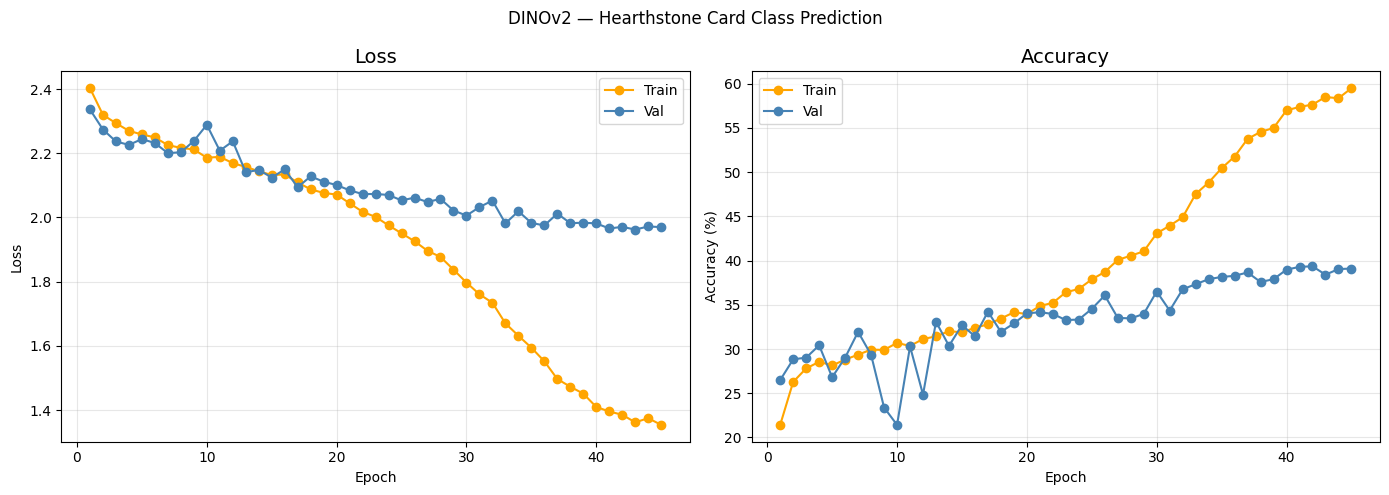


Best model was from epoch 42
Best validation accuracy: 39.35%


In [13]:

# ── Training loop ──────────────────────────────────────────────────────────────
for epoch in range(num_epochs):

    # ── Train ──────────────────────────────────────────────────────────────────
    model.train()
    running_loss, correct, total = 0, 0, 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1:2d}/{num_epochs} [Train]",
                leave=False, unit='batch')

    for imgs, labels in pbar:
        imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.amp.autocast('cuda'):                        # mixed precision
            outputs = model(imgs)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
        total   += labels.size(0)

        pbar.set_postfix({
            'loss': f"{running_loss / (pbar.n + 1):.4f}",
            'acc':  f"{100 * correct / total:.1f}%"
        })

    train_losses.append(running_loss / len(train_loader))
    train_accs.append(100 * correct / total)

    # ── Validate ───────────────────────────────────────────────────────────────
    model.eval()
    running_loss, correct, total = 0, 0, 0

    pbar = tqdm(val_loader, desc=f"Epoch {epoch+1:2d}/{num_epochs} [Val]  ",
                leave=False, unit='batch')

    with torch.no_grad():
        for imgs, labels in pbar:
            imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)

            with torch.amp.autocast('cuda'):
                outputs = model(imgs)
                loss = criterion(outputs, labels)

            running_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
            total   += labels.size(0)

            pbar.set_postfix({
                'loss': f"{running_loss / (pbar.n + 1):.4f}",
                'acc':  f"{100 * correct / total:.1f}%"
            })

    val_losses.append(running_loss / len(val_loader))
    val_accs.append(100 * correct / total)

    current_val_acc = 100 * correct / total

    if current_val_acc > best_val_acc:
        best_val_acc = current_val_acc
        best_epoch = epoch + 1

        torch.save(model.state_dict(), "hearthstone_dinov2_best.pth")

        print(f"✓ New best model saved! "
            f"Val Acc: {best_val_acc:.2f}% "
            f"(Epoch {best_epoch})")

    scheduler.step()

    print(f"Epoch {epoch+1:2d}/{num_epochs}  "
          f"Train loss: {train_losses[-1]:.4f}  acc: {train_accs[-1]:.1f}%  |  "
          f"Val loss: {val_losses[-1]:.4f}  acc: {val_accs[-1]:.1f}%  |  "
          f"LR: {scheduler.get_last_lr()[0]:.6f}")
    

# ── Plot results ───────────────────────────────────────────────────────────────
epochs = range(1, num_epochs + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, train_losses, 'o-', color='orange',    label='Train')
axes[0].plot(epochs, val_losses,   'o-', color='steelblue', label='Val')
axes[0].set_title('Loss', size=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, train_accs, 'o-', color='orange',    label='Train')
axes[1].plot(epochs, val_accs,   'o-', color='steelblue', label='Val')
axes[1].set_title('Accuracy', size=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('DINOv2 — Hearthstone Card Class Prediction')
plt.tight_layout()
plt.savefig('training_results.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Save model ─────────────────────────────────────────────────────────────────
print(f"\nBest model was from epoch {best_epoch}")
print(f"Best validation accuracy: {best_val_acc:.2f}%")

In [14]:
# Load best checkpoint
model.load_state_dict(torch.load("hearthstone_dinov2_best.pth"))
model.eval()

print("Loaded best checkpoint")

Loaded best checkpoint


C:\Users\emilm\AppData\Local\Temp\ipykernel_6256\2454295428.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("hearthstone_dinov2_best.pth

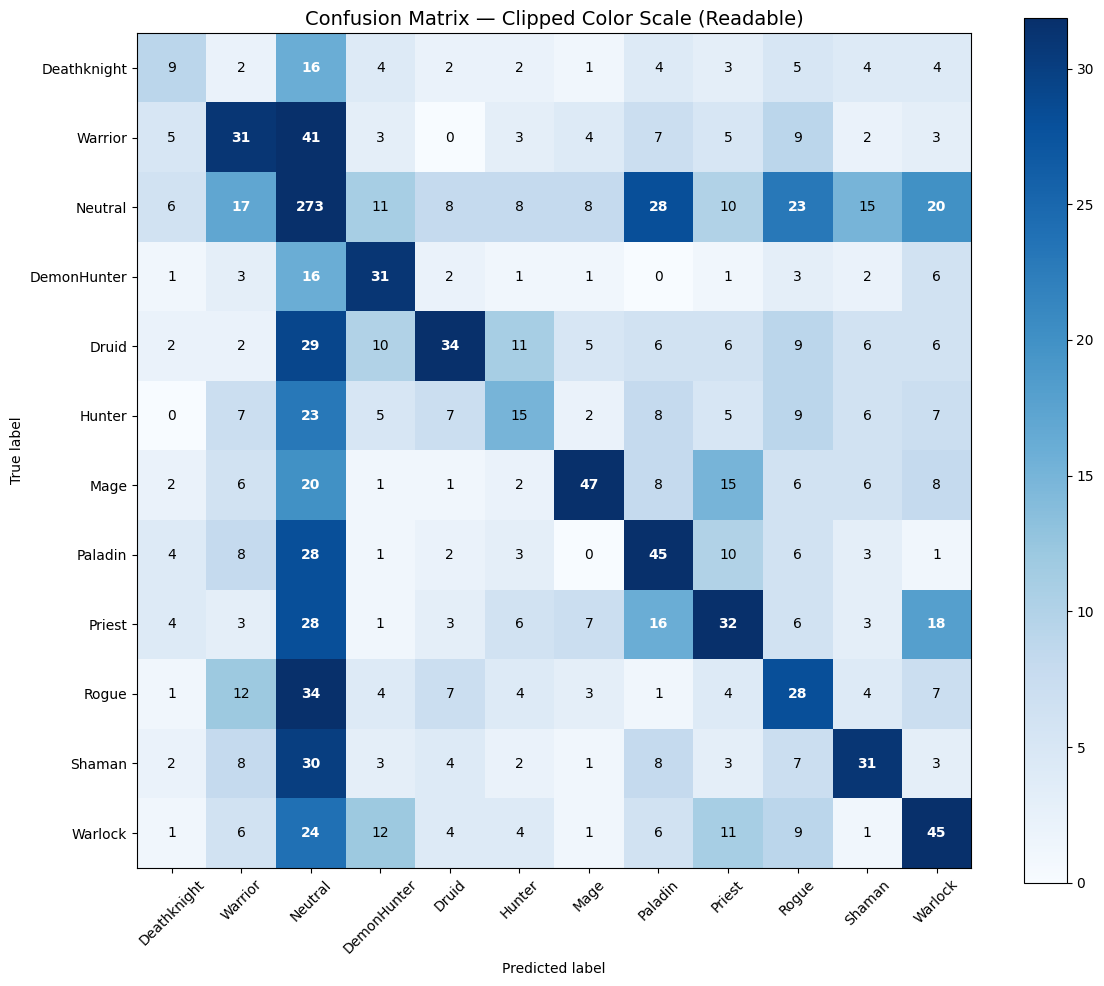

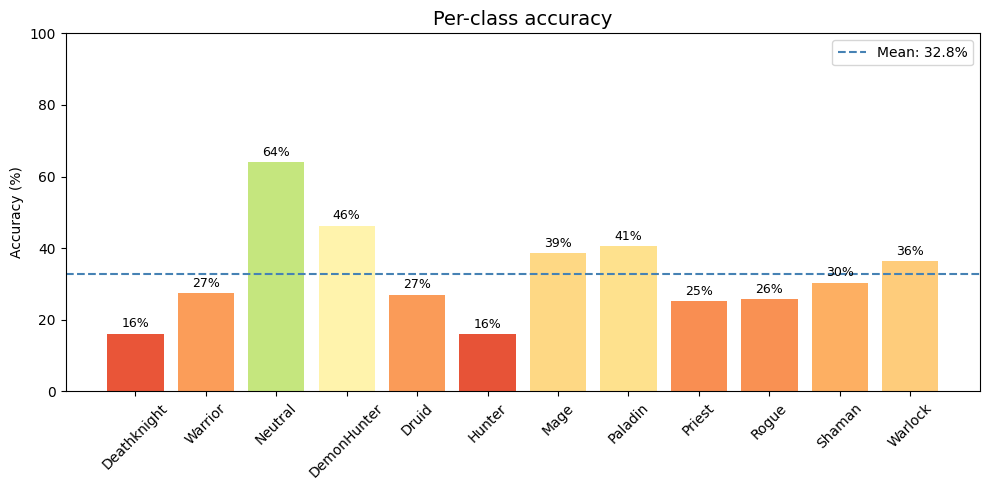

Total misclassified: 957 / 1578


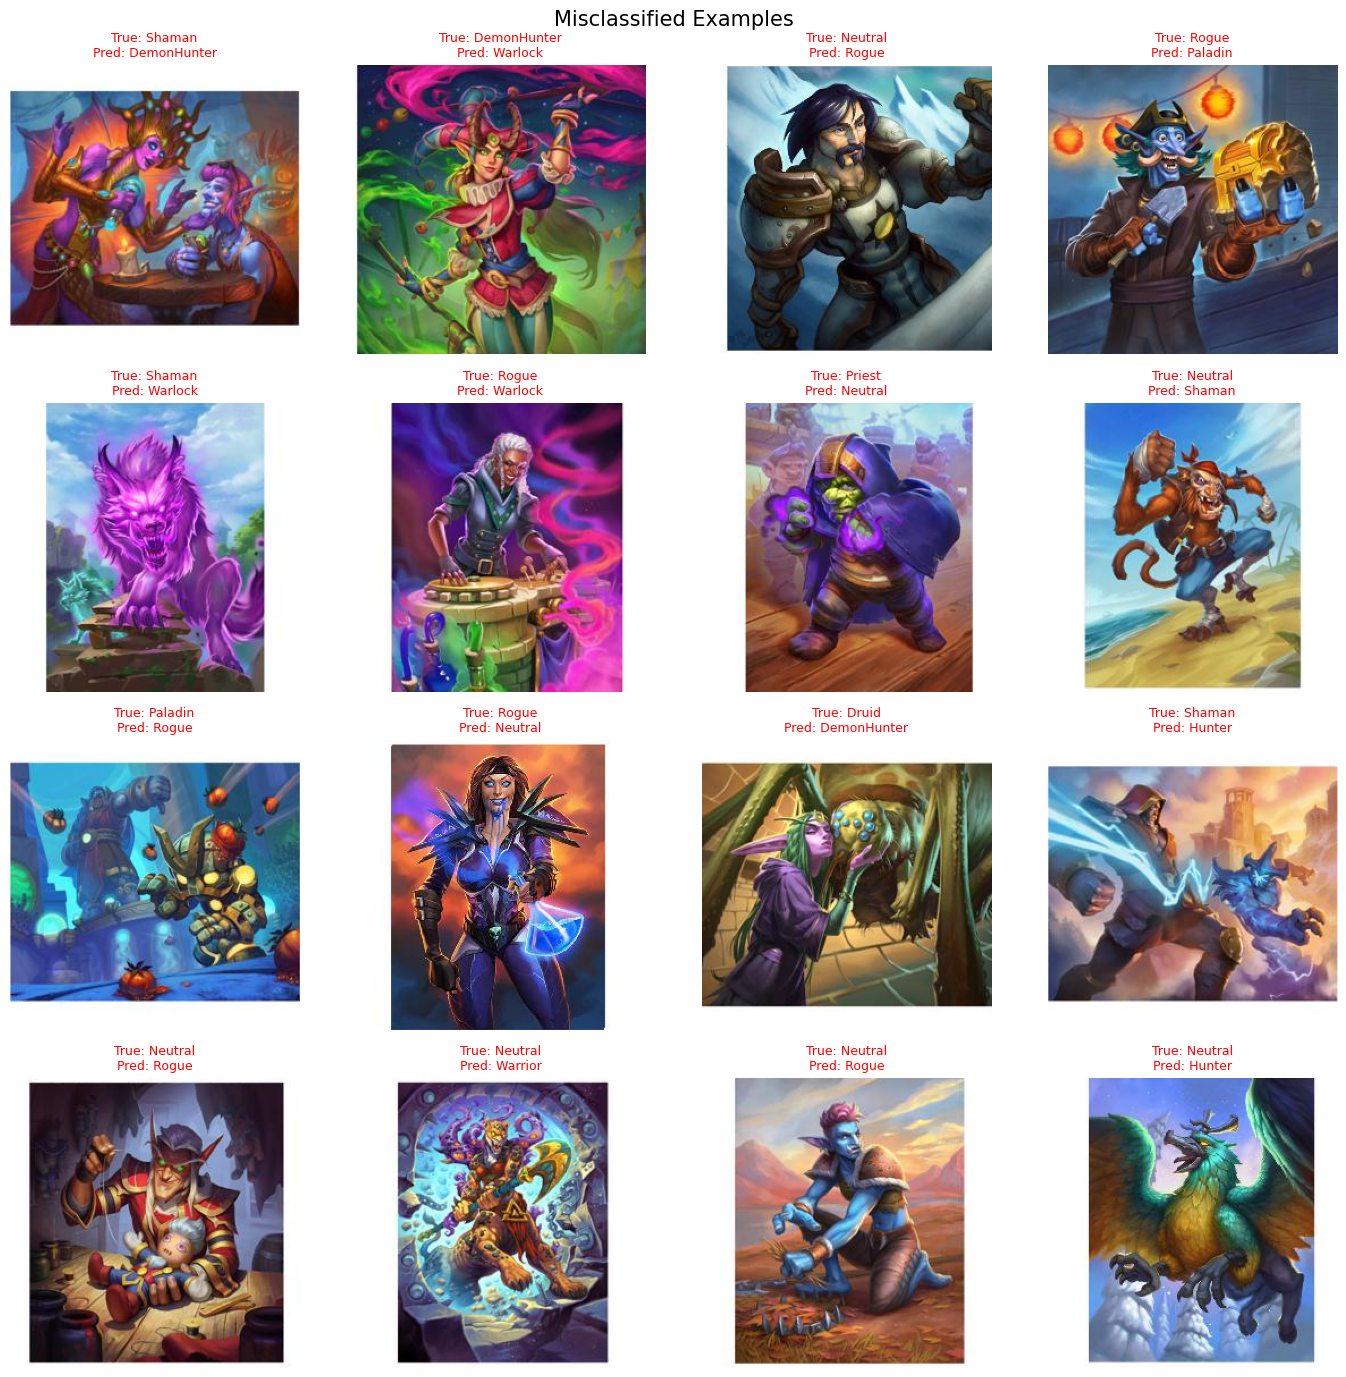


Top 10 most confused class pairs (true → predicted):
          Warrior → Neutral          41 times
            Rogue → Neutral          34 times
           Shaman → Neutral          30 times
            Druid → Neutral          29 times
           Priest → Neutral          28 times
          Paladin → Neutral          28 times
          Neutral → Paladin          28 times
          Warlock → Neutral          24 times
          Neutral → Rogue            23 times
           Hunter → Neutral          23 times


In [15]:

# ── Get all predictions on validation set ──────────────────────────────────────
model.eval()
all_preds, all_labels, all_imgs, all_card_ids = [], [], [], []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        with torch.amp.autocast('cuda'):
            outputs = model(imgs)
        preds = outputs.argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

class_names = full_dataset.le.classes_

CLASS_MAP = {
    '1':'Deathknight','2':'Druid','3':'Hunter','4':'Mage','5':'Paladin',
    '6':'Priest','7':'Rogue','8':'Shaman','9':'Warlock','10':'Warrior',
    '12':'Neutral','14':'DemonHunter'
}

# Map numeric class codes to readable names
class_names_raw = full_dataset.le.classes_
class_names = [CLASS_MAP.get(c, c) for c in class_names_raw]


# ── 1. Confusion matrix ────────────────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)

vmax = np.percentile(cm, 95)    # Clip extreme values for color balance

fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)

disp.plot(
    ax=ax,
    cmap='Blues',
    colorbar=False,
    values_format='d',
    xticks_rotation=45
)

disp.im_.set_clim(vmin=0, vmax=vmax)    # Apply clipping
fig.colorbar(disp.im_, ax=ax)   # Add colorbar

# FIX readable annotations
threshold = vmax / 2

for text, value in zip(ax.texts, cm.flatten()):
    if value > threshold:
        text.set_color('white')
        text.set_fontweight('bold')
    else:
        text.set_color('black')

ax.set_title('Confusion Matrix — Clipped Color Scale (Readable)', size=14)
plt.tight_layout()
plt.show()

# ── 2. Per-class accuracy ──────────────────────────────────────────────────────
per_class_acc = cm.diagonal() / cm.sum(axis=1) * 100

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(class_names, per_class_acc, color=plt.cm.RdYlGn(per_class_acc / 100))
ax.set_title('Per-class accuracy', size=14)
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 100)
ax.axhline(per_class_acc.mean(), color='steelblue', linestyle='--',
           label=f'Mean: {per_class_acc.mean():.1f}%')
ax.legend()
ax.tick_params(axis='x', rotation=45)
for bar, acc in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{acc:.0f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
#plt.savefig('per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 3. Show misclassified examples ────────────────────────────────────────────
# Get indices of wrong predictions
wrong_idx = np.where(all_preds != all_labels)[0]
print(f"Total misclassified: {len(wrong_idx)} / {len(all_labels)}")

# Pick 16 random mistakes to show
sample_idx = np.random.choice(wrong_idx, size=min(16, len(wrong_idx)), replace=False)

# Rebuild val images for display (un-normalized)
val_df = val_dataset.df.reset_index(drop=True)

fig, axes = plt.subplots(4, 4, figsize=(14, 14))
axes = axes.flatten()

for plot_i, val_i in enumerate(sample_idx):
    card_id   = val_df.iloc[val_i]['CardID']
    true_cls  = class_names[all_labels[val_i]]
    pred_cls  = class_names[all_preds[val_i]]

    img = full_dataset.cache.get(card_id)
    if img is not None:
        axes[plot_i].imshow(img)
    axes[plot_i].set_title(f'True: {true_cls}\nPred: {pred_cls}',
                            fontsize=9, color='red')
    axes[plot_i].axis('off')

plt.suptitle('Misclassified Examples', size=15)
plt.tight_layout()
#plt.savefig('misclassified.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 4. Most confused class pairs ──────────────────────────────────────────────
np.fill_diagonal(cm, 0)  # remove correct predictions
confused = []
for i in range(len(class_names)):
    for j in range(len(class_names)):
        if i != j and cm[i, j] > 0:
            confused.append((cm[i, j], class_names[i], class_names[j]))

confused.sort(reverse=True)
print("\nTop 10 most confused class pairs (true → predicted):")
for count, true_cls, pred_cls in confused[:10]:
    print(f"  {true_cls:>15} → {pred_cls:<15}  {count} times")